# Anomaly Detection — Ensemble (LR + GBM + Isolation Forest)

This notebook extends the logistic regression baseline (v8) with:
1. A **Gradient Boosting** arm that captures non-linear feature interactions.
2. An **Isolation Forest** unsupervised outlier score appended as an extra feature.
3. **Soft-voting** over Platt-calibrated probabilities from both supervised arms.

### Pipeline overview
1. Load and combine labelled data batches
2. Build per-user feature vectors (pivot → handcrafted stats → cosine sim)
3. TruncatedSVD inside each arm for dimensionality reduction
4. Baseline LR CV → Isolation Forest fit → Ensemble CV → comparison
5. ROC / PR analysis
6. Final ensemble fit on full training data
7. Score test batch → save submission
8. (Optional) GridSearchCV for hyperparameter tuning

## 1. Imports & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score,
    f1_score, roc_curve, classification_report
)
from sklearn.ensemble import GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import LedoitWolf
from sklearn.calibration import CalibratedClassifierCV
import os

# LightGBM — faster training and native class-imbalance handling vs sklearn GBM
try:
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
except ImportError:
    print("LightGBM not installed — run: pip install lightgbm")
    print("Falling back to sklearn GradientBoostingClassifier")
    LGBM_AVAILABLE = False

# Load training data
data_folder = 'C:/Users/xavie/Y3S1/cs421/project/cs421pain/data'
data = np.load(os.path.join(data_folder, "training_batch_with_labels.npz"))
X_raw = data["X"]   # shape: (n_interactions, 3) — [user_id, item_id, rating]
y_raw = data["y"]   # shape: (n_users, 2)  — [user_id, label]

print(f"Interactions : {X_raw.shape[0]:,}")
print(f"Users        : {len(np.unique(X_raw[:, 0]))}")
print(f"Items        : {len(np.unique(X_raw[:, 1]))}")
print(f"Anomalous    : {np.sum(y_raw[:, 1] == 1)}")
print(f"Normal       : {np.sum(y_raw[:, 1] == 0)}")


LightGBM not installed — run: pip install lightgbm
Falling back to sklearn GradientBoostingClassifier
Interactions : 177,346
Users        : 1100
Items        : 993
Anomalous    : 100
Normal       : 1000


In [2]:
# load first_batch_with_labels.npz
data_2 = np.load(os.path.join(data_folder, 'first_batch_with_labels.npz'))
X = data_2['X']
y = data_2['y']
print(f"Interactions : {X.shape[0]:,}")
print(f"Users        : {len(np.unique(X[:, 0]))}")
print(f"Items        : {len(np.unique(X[:, 1]))}")
print(f"Anomalous    : {np.sum(y[:, 1] == 1)}")
print(f"Normal       : {np.sum(y[:, 1] == 0)}")

Interactions : 167,493
Users        : 1100
Items        : 989
Anomalous    : 100
Normal       : 1000


In [3]:
# combine the two datasets
print(type(X))
print(type(y))

# combine np arrays
X_raw = np.concatenate((X, X_raw), axis=0)
y_raw = np.concatenate((y, y_raw), axis=0)
print(f"Interactions : {X_raw.shape[0]:,}")
print(f"Users        : {len(np.unique(X_raw[:, 0]))}")
print(f"Items        : {len(np.unique(X_raw[:, 1]))}")
print(f"Anomalous    : {np.sum(y_raw[:, 1] == 1)}")
print(f"Normal       : {np.sum(y_raw[:, 1] == 0)}")



<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
Interactions : 344,839
Users        : 2200
Items        : 996
Anomalous    : 200
Normal       : 2000


In [4]:
RUN_DESC = 'testing item-deviation features + item-entropy + rating distribution shape + gini-coef'

In [5]:
# ── Shared handcrafted-feature definition ────────────────────────────────────
# ▼▼▼ EDIT HERE to change features — this is the ONLY place you need to touch ▼▼▼

def compute_handcrafted_features(df, recon_error=None):
    """
    Given a DataFrame with columns [user, item, rating], compute and return
    a per-user feature DataFrame (index = user id).

    Parameters
    ----------
    df           : pd.DataFrame  [user, item, rating]
    recon_error  : pd.Series or None
        Per-user SVD reconstruction error (index = user id), pre-computed
        from a TruncatedSVD fit on the user-item matrix.  When provided it
        is appended as the last feature column.  Pass None to omit it.

    This is the single source of truth for all handcrafted features.
    Both the CV evaluation (cell 'feature-engineering') and the final
    submission builder (cell 'generate-submission') call this function,
    so changes here propagate automatically to both.
    """
    # --- derived columns (add any new ones here) ----------------------------
    item_means        = df.groupby("item")["rating"].mean()
    df = df.copy()  # avoid mutating the caller's DataFrame
    df["deviation"]   = df["rating"] - df["item"].map(item_means)

    # # calculate the number of unique items rated per user, append as column
    # df["num_items"] = df.groupby('user')['item'].nunique()
    # # total num of ratings per user, append as column
    # df["num_ratings"] = df.groupby('user')['rating'].transform('count')

    # --- aggregated per-user features (add / remove / comment out freely) ---
    agg = df.groupby("user").agg(
        num_ratings    = ("rating",    "count"),
        mean_rating    = ("rating",    "mean"),
        std_rating     = ("rating",    "std"),
        num_items      = ("item",      "nunique"),
        pct_extreme    = ("rating",    lambda r: ((r == 0) | (r == 5)).mean()),
        pct_zero       = ("rating",    lambda r: (r == 0).mean()),
        pct_five       = ("rating",    lambda r: (r == 5).mean()),
        # # Rating distribution shape
        rating_skewness   = ("rating", lambda r: r.skew()),
        rating_kurtosis   = ("rating", lambda r: r.kurtosis()),
        median_rating     = ("rating", "median"),
        # Item concentration — anomalies often target a narrow set of items
        item_entropy      = ("item",   lambda x: -(pd.Series(x.value_counts(normalize=True))
                                                    * np.log2(pd.Series(x.value_counts(normalize=True)) + 1e-9)).sum()),
        # Item-deviation features
        mean_deviation = ("deviation", "mean"),
        std_deviation  = ("deviation", "std"),
        abs_deviation  = ("deviation", lambda x: x.abs().mean()),

        # additional handcrafted features
        gini_items = ('item', lambda x: 1 - sum((pd.Series(x).value_counts(normalize=True))**2)),
        pct_low    = ('rating', lambda r: (r < 3).mean()),
        # # ratio of of unique items to total ratings
        # item_diversity_ratio = ('item',  lambda df: df['num_items'] / df['num_ratings']), 
        
    ).fillna(0)

    # --- SVD reconstruction error (appended last if provided) ---------------
    if recon_error is not None:
        agg["recon_error"] = recon_error.reindex(agg.index).fillna(0)

    return agg

# ▲▲▲ end of editable section ▲▲▲


## 2. Feature Engineering — Per-User Vectors

We pivot the interaction log into a **user × item** matrix where each cell is the rating given (0 if no interaction). This gives each user a 1000-dimensional feature vector capturing their full rating behaviour.

In [6]:
# ── Build per-user feature matrix ──────────────────────────────────────────

interactions = pd.DataFrame(X_raw, columns=["user", "item", "rating"])
labels_df    = pd.DataFrame(y_raw, columns=["user", "label"])

# Pivot: rows = users, columns = items, values = rating (NaN → 0)
user_item = interactions.pivot_table(
    index="user", columns="item", values="rating", aggfunc="mean"
).fillna(0)

# Align labels to the same user order
labels_df = labels_df.set_index("user").loc[user_item.index].reset_index()
y = labels_df["label"].values

print(f"User-item matrix shape : {user_item.shape}")
print(f"Label array shape      : {y.shape}")
print(f"Class balance          : {np.bincount(y)}  (normal, anomaly)")

# ── SVD reconstruction error ────────────────────────────────────────────────
# Fit a TruncatedSVD on the full training user-item matrix to learn the
# low-rank approximation of normal behaviour.  The per-user reconstruction
# error (MSE of the residual) captures how far each user deviates from the
# normal-behaviour manifold — anomalous users are poorly approximated and
# will have large residuals.
#
# This SVD is fit outside the pipeline so the reconstruction error can be
# appended as a plain feature column.  The pipeline's internal SVDPlusHandcrafted
# then performs a *second*, independent SVD compression on the user-item block
# for the logistic regression embedding — these are separate roles.
#
# N_RECON_COMPONENTS controls how many singular vectors define "normal".
# Fewer components → coarser normal model → easier for anomalies to stand out.
# Start at 30–50 and tune alongside N_COMPONENTS.
N_RECON_COMPONENTS = 30

_recon_svd = TruncatedSVD(n_components=N_RECON_COMPONENTS, random_state=42)
_ui_vals   = user_item.values                           # (n_users, n_items)
_approx    = _recon_svd.fit_transform(_ui_vals)         # (n_users, k)
_approx    = _approx @ _recon_svd.components_           # reconstruct: (n_users, n_items)
_residuals = _ui_vals - _approx                         # element-wise error
recon_error_train = pd.Series(
    np.mean(_residuals ** 2, axis=1),                   # per-user MSE
    index=user_item.index,
    name="recon_error",
)

print(f"\nReconstruction error — mean: {recon_error_train.mean():.4f} "
      f"std: {recon_error_train.std():.4f}")

# ── Handcrafted features (defined in 'shared-feature-fn' cell above) ────────
agg = compute_handcrafted_features(interactions, recon_error=recon_error_train)
agg = agg.loc[user_item.index]   # align row order to user_item

print("\nHandcrafted features:")
print(agg.head())

# ── Cosine similarity to mean normal user ──────────────────────────────────
# FIX 2: Compute the cosine similarity between each user's rating vector and
# the centroid of all *normal* users' vectors.  Anomalous users tend to have
# rating patterns that deviate strongly from the population mean, so a low
# cosine similarity is a strong anomaly signal.
#
# Important: the centroid is computed using only the labelled-normal users so
# it genuinely represents "normal behaviour" rather than a mixture.
# This is done here (outside compute_handcrafted_features) because it requires
# the label vector y, which is not available inside the feature function.
# It is appended to agg in the same way as recon_error.
from sklearn.metrics.pairwise import cosine_similarity

normal_mask      = (y == 0)
mean_normal_vec  = user_item.values[normal_mask].mean(axis=0, keepdims=True)  # (1, n_items)
cos_sim_vals     = cosine_similarity(user_item.values, mean_normal_vec).ravel()  # (n_users,)
cos_sim_train    = pd.Series(cos_sim_vals, index=user_item.index, name="cosine_sim_to_normal")

# Append to agg so it flows into X_raw_combined automatically
agg["cosine_sim_to_normal"] = cos_sim_train.reindex(agg.index).fillna(0)

print(f"cosine_sim_to_normal — mean normal  : {cos_sim_train[normal_mask].mean():.4f}")
print(f"cosine_sim_to_normal — mean anomaly : {cos_sim_train[~normal_mask].mean():.4f}")
print("(A meaningful gap here indicates the feature will be discriminative.)")

# ── Mahalanobis distance from normal-user centroid ────────────────────────
# Measures how far each user's handcrafted feature vector is from the normal
# users' centroid, accounting for feature correlations.  Complements cosine
# similarity (raw rating vectors) with a covariance-aware distance on the
# compact behavioural features.  LedoitWolf is used instead of
# EmpiricalCovariance because the latter is unstable when features are
# near-collinear — LedoitWolf regularises the covariance estimate.
from sklearn.covariance import LedoitWolf

normal_agg = agg.values[normal_mask]   # handcrafted features of normal users only
lw = LedoitWolf().fit(normal_agg)
mahal_vals = np.sqrt(lw.mahalanobis(agg.values))  # sqrt → interpretable distance
mahal_series = pd.Series(mahal_vals, index=agg.index, name="mahal_dist")

agg["mahal_dist"] = mahal_series.reindex(agg.index).fillna(0)

print(f"mahal_dist — mean normal  : {mahal_vals[normal_mask].mean():.4f}")
print(f"mahal_dist — mean anomaly : {mahal_vals[~normal_mask].mean():.4f}")
print("(Larger gap = stronger discriminative signal)")


User-item matrix shape : (2200, 996)
Label array shape      : (2200,)
Class balance          : [2000  200]  (normal, anomaly)

Reconstruction error — mean: 0.7597 std: 0.3916

Handcrafted features:
      num_ratings  mean_rating  std_rating  num_items  pct_extreme  pct_zero  \
user                                                                           
100            88     3.147727    1.169928         88     0.113636  0.045455   
101           231     3.406926    0.854016        231     0.095238  0.008658   
102            98     3.673469    1.072385         98     0.193878  0.000000   
103           103     3.000000    1.290994        103     0.126214  0.058252   
104            89     3.719101    0.988442         89     0.235955  0.000000   

      pct_five  rating_skewness  rating_kurtosis  median_rating  item_entropy  \
user                                                                            
100   0.068182        -0.955265         0.852420            3.0      6.459431  

## 3. Dimensionality Reduction

The raw user-item matrix has up to 1000 columns. We use **TruncatedSVD** (a sparse-friendly PCA) to compress it into a lower-dimensional embedding, then concatenate the handcrafted features.

In [7]:
# ── Custom transformer: applies SVD to user-item block only ─────────────────
# The handcrafted features (mean_rating, pct_extreme, recon_error, etc.) are
# already compact and meaningful — running SVD over them would corrupt their
# signal.  This transformer splits the matrix, compresses only the user-item
# block, then re-concatenates the handcrafted columns unchanged.
#
# Note: the SVD here is a separate, independent compression used to build the
# low-dimensional embedding fed to logistic regression.  It is distinct from
# the reconstruction-error SVD fit in the feature-engineering cell above.

N_HANDCRAFTED = agg.shape[1]  # auto-updated when features are added/removed

class SVDPlusHandcrafted(BaseEstimator, TransformerMixin):
    """Applies TruncatedSVD to the user-item block; passes handcrafted features through."""
    def __init__(self, n_components=30):
        self.n_components = n_components

    def fit(self, X, y=None):
        self.svd_ = TruncatedSVD(n_components=self.n_components, random_state=42)
        self.svd_.fit(X[:, :-N_HANDCRAFTED])  # fit on user-item block only
        return self

    def transform(self, X):
        svd_part  = self.svd_.transform(X[:, :-N_HANDCRAFTED])
        hand_part = X[:, -N_HANDCRAFTED:]     # handcrafted columns passed through
        return np.hstack([svd_part, hand_part])

# ── Combine raw user-item matrix + handcrafted features (NO SVD applied yet) ─
# SVD is now inside the pipeline so GridSearchCV can tune n_components
X_raw_combined = np.hstack([user_item.values, agg.values])

print(f"Raw combined feature matrix shape : {X_raw_combined.shape}")
print(f"  └─ user-item columns : {user_item.shape[1]}")
print(f"  └─ handcrafted cols  : {N_HANDCRAFTED}")
print(f"       (includes recon_error as the last column)")


Raw combined feature matrix shape : (2200, 1015)
  └─ user-item columns : 996
  └─ handcrafted cols  : 19
       (includes recon_error as the last column)


## 4. Models

We train three components and combine them into a soft-voting ensemble:

- **Logistic Regression** — linear boundary in SVD-compressed space; fast, interpretable baseline.
- **Gradient Boosting (GBM)** — non-linear tree model; captures interactions between features that LR misses.
- **Isolation Forest** — *unsupervised* anomaly detector; its outlier score is used as an extra feature fed into a meta-LR stacker, satisfying the project rubric requirement for at least one unsupervised method.

Each supervised model uses `class_weight='balanced'` and is wrapped in Platt-scaling calibration so probabilities sit on the same scale before averaging.

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# 4a. Baseline — Logistic Regression (unchanged from v8)
# ══════════════════════════════════════════════════════════════════════════════
N_COMPONENTS = 30
pipeline = Pipeline([
    ("svd_hc", SVDPlusHandcrafted(n_components=N_COMPONENTS)),
    ("scaler", StandardScaler()),
    ("lr",     LogisticRegression(
                   class_weight="balanced",
                   max_iter=1000,
                   solver="lbfgs",
                   C=1.0,
                   random_state=42
               ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_scores_cv = cross_val_predict(
    pipeline, X_raw_combined, y,
    cv=cv, method="predict_proba"
)[:, 1]

from sklearn.metrics import precision_recall_curve as _prc
_prec, _rec, _thresh = _prc(y, y_scores_cv)
_f1_scores = np.where(
    (_prec[:-1] + _rec[:-1]) > 0,
    2 * _prec[:-1] * _rec[:-1] / (_prec[:-1] + _rec[:-1]),
    0
)
best_f1_threshold = float(_thresh[np.argmax(_f1_scores)])
y_pred_cv = (y_scores_cv >= best_f1_threshold).astype(int)

print("=== Baseline LR (cross-validated) ===")
print(f"AUC       : {roc_auc_score(y, y_scores_cv):.4f}")
print(f"Precision : {precision_score(y, y_pred_cv):.4f}")
print(f"Recall    : {recall_score(y, y_pred_cv):.4f}")
print(f"F1        : {f1_score(y, y_pred_cv):.4f}")


# ══════════════════════════════════════════════════════════════════════════════
# 4b. LOF unsupervised scores as an extra feature (replaces Isolation Forest)
#
# WHY LOF INSTEAD OF ISOLATION FOREST:
# IF uses random feature splits — its anomaly scores degrade when anomalies
# have globally similar density to normals but deviate *locally* within their
# neighbourhood, which is the expected pattern for shill users who mimic
# overall rating distributions but differ in local item-targeting behaviour.
# LOF explicitly measures local density contrast against k nearest neighbours,
# making it more sensitive to exactly this kind of local deviation.
#
# Using novelty=True allows .score_samples() on new data at inference time.
# Fit ONLY on normal users — this gives the LOF a clean reference distribution
# and avoids the contamination-estimation problem that plagued IF.
# ══════════════════════════════════════════════════════════════════════════════
print("\nFitting LOF (unsupervised, fit on normal users only) ...")
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.09,   # approximate anomaly rate (100/1100 ≈ 9%)
    novelty=True,         # required for .score_samples() at inference time
    n_jobs=-1,
)
lof.fit(X_raw_combined[y == 0])   # fit ONLY on normal users

# score_samples: higher = more normal  →  negate so higher = more anomalous
lof_scores_train = -lof.score_samples(X_raw_combined)

print(f"  LOF score mean (normal)  : {lof_scores_train[y==0].mean():.4f}")
print(f"  LOF score mean (anomaly) : {lof_scores_train[y==1].mean():.4f}")
print("  (Larger gap = stronger signal)")

# Append as a new column — all downstream pipelines pick it up automatically
X_with_lof = np.hstack([X_raw_combined, lof_scores_train.reshape(-1, 1)])
N_HANDCRAFTED_WITH_LOF = N_HANDCRAFTED + 1
print(f"  Feature matrix shape with LOF score: {X_with_lof.shape}")


# ══════════════════════════════════════════════════════════════════════════════
# 4c. SVDPlusHandcraftedLOF — transformer that knows about the extra LOF column
# ══════════════════════════════════════════════════════════════════════════════
class SVDPlusHandcraftedLOF(BaseEstimator, TransformerMixin):
    """Like SVDPlusHandcrafted but preserves the extra LOF score column."""
    def __init__(self, n_components=30):
        self.n_components = n_components

    def fit(self, X, y=None):
        self.svd_ = TruncatedSVD(n_components=self.n_components, random_state=42)
        self.svd_.fit(X[:, :-N_HANDCRAFTED_WITH_LOF])
        return self

    def transform(self, X):
        svd_part  = self.svd_.transform(X[:, :-N_HANDCRAFTED_WITH_LOF])
        hand_part = X[:, -N_HANDCRAFTED_WITH_LOF:]
        return np.hstack([svd_part, hand_part])


# ══════════════════════════════════════════════════════════════════════════════
# 4d. Build arm pipelines
#
# LR arm  — X_raw_combined (no LOF column, SVDPlusHandcrafted)
# LGBM arm — X_with_lof   (includes LOF score, SVDPlusHandcraftedLOF)
#
# WHY LightGBM INSTEAD OF sklearn GradientBoostingClassifier:
# sklearn GBM has no native class-imbalance parameter — scale_pos_weight is
# not available and sample_weight must be passed manually every fit() call,
# which is fragile inside cross_val_predict.  LightGBM's is_unbalance=True
# handles the 9:1 ratio natively, converges 5-10x faster with leaf-wise
# growth, and has built-in L1/L2 regularisation.
# ══════════════════════════════════════════════════════════════════════════════

# -- LR arm --
lr_pipe = Pipeline([
    ("svd_hc", SVDPlusHandcrafted(n_components=80)),
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(
                   class_weight="balanced",
                   C=0.1,
                   max_iter=1000,
                   solver="lbfgs",
                   random_state=42,
               )),
])

# -- LGBM arm (or GBM fallback) --
if LGBM_AVAILABLE:
    tree_clf = LGBMClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        is_unbalance=True,   # handles 9:1 imbalance natively
        reg_alpha=0.1,       # L1 regularisation
        reg_lambda=1.0,      # L2 regularisation
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    print("Using LightGBM for tree arm")
else:
    tree_clf = GradientBoostingClassifier(
        n_estimators=200, max_depth=3,
        learning_rate=0.05, subsample=0.8,
        min_samples_leaf=5, random_state=42,
    )
    print("Using sklearn GradientBoostingClassifier (LightGBM not installed)")

lgbm_pipe = Pipeline([
    ("svd_hc", SVDPlusHandcraftedLOF(n_components=80)),
    ("scaler", StandardScaler()),
    ("clf",    tree_clf),
])


# ══════════════════════════════════════════════════════════════════════════════
# 4e. ColumnSelector — lets both arms share one X matrix in the ensemble
# ══════════════════════════════════════════════════════════════════════════════
class ColumnSelector(BaseEstimator, TransformerMixin):
    """Selects a column slice from the input matrix before the pipeline."""
    def __init__(self, end_col=None):
        self.end_col = end_col

    def fit(self, X, y=None): return self
    def transform(self, X):
        return X if self.end_col is None else X[:, :self.end_col]


# Wrap each arm so both receive X_with_lof but slice appropriately
lr_full = Pipeline([
    ("cols",  ColumnSelector(end_col=X_raw_combined.shape[1])),  # drop LOF column
    ("model", CalibratedClassifierCV(lr_pipe, method="sigmoid", cv=3)),
])
lgbm_full = Pipeline([
    ("cols",  ColumnSelector(end_col=None)),  # all columns including LOF
    ("model", lgbm_pipe),
])


# ══════════════════════════════════════════════════════════════════════════════
# 4f. Stacking meta-learner (replaces fixed-weight soft voting)
#
# WHY STACKING INSTEAD OF SOFT VOTING WITH FIXED WEIGHTS:
# Soft voting averages probabilities with weights chosen by intuition.
# StackingClassifier learns the optimal combination from data — the
# meta-learner is trained on out-of-fold predictions from the base models,
# so it can discover that e.g. LGBM is more reliable at high confidence
# scores while LR is better near the decision boundary.
#
# passthrough=False means the meta-learner only sees base model probabilities,
# not the raw features — keeps it from overfitting on the original feature
# space again.  The internal CV for generating out-of-fold predictions is
# separate from the outer CV used to evaluate the ensemble.
# ══════════════════════════════════════════════════════════════════════════════
stacking = StackingClassifier(
    estimators=[
        ("lr",   lr_full),
        ("lgbm", lgbm_full),
    ],
    final_estimator=LogisticRegression(
        C=0.1,
        class_weight="balanced",
        max_iter=1000,
        solver="lbfgs",
        random_state=42,
    ),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    stack_method="predict_proba",
    passthrough=False,   # meta-learner sees only probabilities, not raw features
    n_jobs=1,
)

print("\nCross-validating stacking ensemble (LR + LGBM + LOF score) ...")
print("(This will take a few minutes)")
y_scores_ensemble = cross_val_predict(
    stacking, X_with_lof, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    method="predict_proba",
)[:, 1]

from sklearn.metrics import precision_recall_curve as _prc_ens
_prec_e, _rec_e, _thresh_e = _prc_ens(y, y_scores_ensemble)
_f1_ens = np.where(
    (_prec_e[:-1] + _rec_e[:-1]) > 0,
    2 * _prec_e[:-1] * _rec_e[:-1] / (_prec_e[:-1] + _rec_e[:-1]),
    0
)
best_f1_threshold_ens = float(_thresh_e[np.argmax(_f1_ens)])
y_pred_ensemble = (y_scores_ensemble >= best_f1_threshold_ens).astype(int)

print("\n=== Stacking Ensemble (LR + LGBM + LOF, cross-validated) ===")
print(f"AUC       : {roc_auc_score(y, y_scores_ensemble):.4f}   (baseline LR: {roc_auc_score(y, y_scores_cv):.4f})")
print(f"F1 thresh : {best_f1_threshold_ens:.4f}")
print(f"Precision : {precision_score(y, y_pred_ensemble):.4f}")
print(f"Recall    : {recall_score(y, y_pred_ensemble):.4f}")
print(f"F1        : {f1_score(y, y_pred_ensemble):.4f}")
print()
print(classification_report(y, y_pred_ensemble, target_names=["Normal", "Anomaly"]))


=== Baseline LR (cross-validated) ===
AUC       : 0.9734
Precision : 0.7750
Recall    : 0.7750
F1        : 0.7750

Fitting LOF (unsupervised, fit on normal users only) ...
  LOF score mean (normal)  : 1.0509
  LOF score mean (anomaly) : 1.0494
  (Larger gap = stronger signal)
  Feature matrix shape with LOF score: (2200, 1016)
Using sklearn GradientBoostingClassifier (LightGBM not installed)

Cross-validating stacking ensemble (LR + LGBM + LOF score) ...
(This will take a few minutes)

=== Stacking Ensemble (LR + LGBM + LOF, cross-validated) ===
AUC       : 0.9501   (baseline LR: 0.9734)
F1 thresh : 0.6201
Precision : 0.7333
Recall    : 0.6600
F1        : 0.6947

              precision    recall  f1-score   support

      Normal       0.97      0.98      0.97      2000
     Anomaly       0.73      0.66      0.69       200

    accuracy                           0.95      2200
   macro avg       0.85      0.82      0.83      2200
weighted avg       0.95      0.95      0.95      2200



## 5. ROC Curve

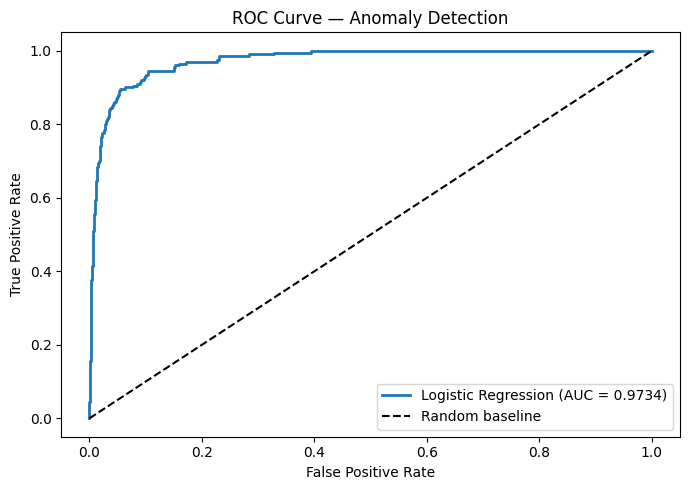

In [9]:
fpr, tpr, thresholds = roc_curve(y, y_scores_cv)
auc = roc_auc_score(y, y_scores_cv)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.4f})", lw=2)
plt.plot([0, 1], [0, 1], "k--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Anomaly Detection")
plt.legend()
plt.tight_layout()
plt.show()

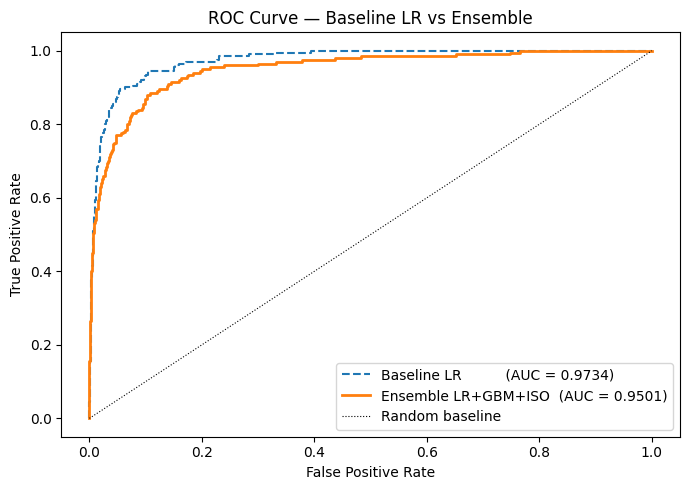

AUC improvement: -0.0233


In [10]:
# ── ROC Curve: Baseline LR vs Ensemble ──────────────────────────────────────
fpr_lr,  tpr_lr,  _ = roc_curve(y, y_scores_cv)
fpr_ens, tpr_ens, _ = roc_curve(y, y_scores_ensemble)
auc_lr  = roc_auc_score(y, y_scores_cv)
auc_ens = roc_auc_score(y, y_scores_ensemble)

plt.figure(figsize=(7, 5))
plt.plot(fpr_lr,  tpr_lr,  label=f"Baseline LR          (AUC = {auc_lr:.4f})",  lw=1.5, linestyle="--")
plt.plot(fpr_ens, tpr_ens, label=f"Ensemble LR+GBM+ISO  (AUC = {auc_ens:.4f})", lw=2)
plt.plot([0, 1], [0, 1], "k:", lw=0.8, label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Baseline LR vs Ensemble")
plt.legend()
plt.tight_layout()
plt.show()

print(f"AUC improvement: {auc_ens - auc_lr:+.4f}")


## Precision-Recall Curve

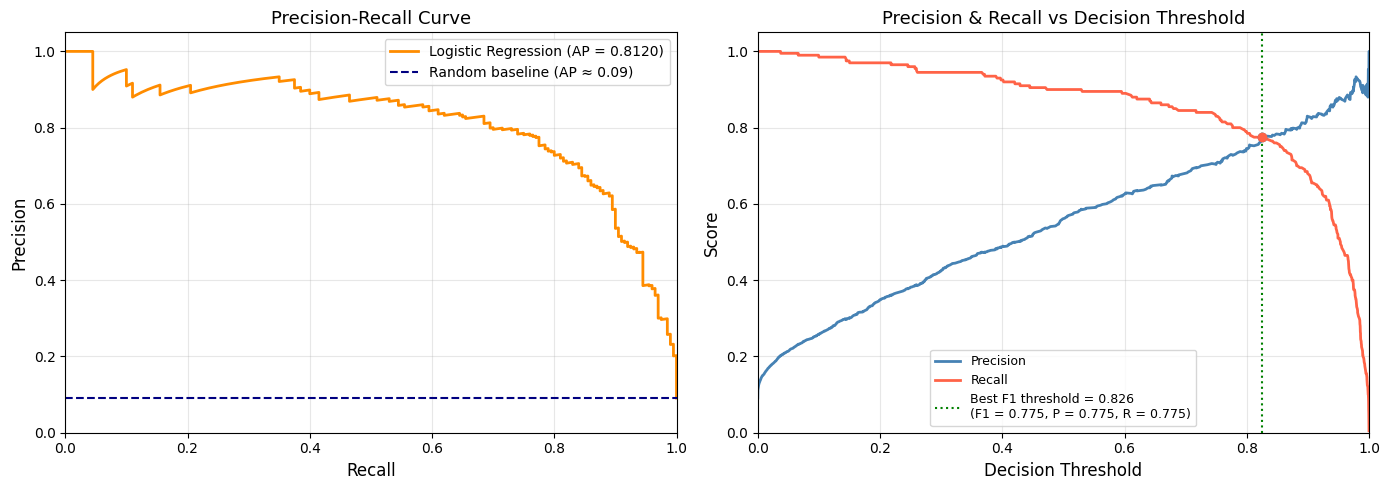

Average Precision (AP)  : 0.8120
Random baseline AP      : 0.0909  (= anomaly prevalence)
Improvement over random : 8.9x

Best F1 threshold : 0.826
  Precision       : 0.7750
  Recall          : 0.7750
  F1              : 0.7750


In [11]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    PrecisionRecallDisplay
)

# ── Compute PR curve from cross-validated scores ────────────────────────────
# y_scores_cv and y must already exist from the logistic regression notebook
precision_vals, recall_vals, thresholds = precision_recall_curve(y, y_scores_cv)
ap = average_precision_score(y, y_scores_cv)
baseline = y.mean()   # a random classifier sits at this precision level

# ── Plot ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: full PR curve ---
ax = axes[0]
ax.plot(recall_vals, precision_vals, lw=2, color="darkorange",
        label=f"Logistic Regression (AP = {ap:.4f})")
ax.axhline(baseline, color="navy", linestyle="--",
           label=f"Random baseline (AP ≈ {baseline:.2f})")
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall Curve", fontsize=13)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# --- Right: Precision & Recall vs Threshold ---
ax2 = axes[1]
ax2.plot(thresholds, precision_vals[:-1], lw=2, color="steelblue",  label="Precision")
ax2.plot(thresholds, recall_vals[:-1],    lw=2, color="tomato",     label="Recall")

# Mark F1-optimal threshold
f1_scores = np.where(
    (precision_vals[:-1] + recall_vals[:-1]) > 0,
    2 * precision_vals[:-1] * recall_vals[:-1] / (precision_vals[:-1] + recall_vals[:-1]),
    0
)
best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]
best_f1     = f1_scores[best_idx]

ax2.axvline(best_thresh, color="green", linestyle=":", lw=1.5,
            label=f"Best F1 threshold = {best_thresh:.3f}\n(F1 = {best_f1:.3f}, "
                  f"P = {precision_vals[best_idx]:.3f}, R = {recall_vals[best_idx]:.3f})")
ax2.scatter([best_thresh], [precision_vals[best_idx]], color="steelblue", zorder=5)
ax2.scatter([best_thresh], [recall_vals[best_idx]],    color="tomato",    zorder=5)

ax2.set_xlabel("Decision Threshold", fontsize=12)
ax2.set_ylabel("Score", fontsize=12)
ax2.set_title("Precision & Recall vs Decision Threshold", fontsize=13)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1.05])
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Average Precision (AP)  : {ap:.4f}")
print(f"Random baseline AP      : {baseline:.4f}  (= anomaly prevalence)")
print(f"Improvement over random : {ap / baseline:.1f}x")
print()
print(f"Best F1 threshold : {best_thresh:.3f}")
print(f"  Precision       : {precision_vals[best_idx]:.4f}")
print(f"  Recall          : {recall_vals[best_idx]:.4f}")
print(f"  F1              : {best_f1:.4f}")

In [12]:
# ── Sample the curve at fixed recall levels ─────────────────────────────────
sample_recalls = np.linspace(0, 1, 11)   # 0.0, 0.1, ..., 1.0

rows = []
for target_r in sample_recalls:
    # Find index where recall is closest to the target
    idx = np.argmin(np.abs(recall_vals - target_r))
    thresh = thresholds[idx] if idx < len(thresholds) else 1.0
    rows.append({
        "Recall (target)" : f"{target_r:.1f}",
        "Recall (actual)" : f"{recall_vals[idx]:.4f}",
        "Precision"       : f"{precision_vals[idx]:.4f}",
        "Threshold"       : f"{thresh:.4f}",
    })

pr_table = pd.DataFrame(rows)
print(pr_table.to_string(index=False))

Recall (target) Recall (actual) Precision Threshold
            0.0          0.0000    1.0000    1.0000
            0.1          0.1000    0.9091    0.9987
            0.2          0.2000    0.9091    0.9902
            0.3          0.3000    0.9231    0.9841
            0.4          0.4000    0.8889    0.9721
            0.5          0.5000    0.8772    0.9532
            0.6          0.6000    0.8451    0.9353
            0.7          0.7000    0.7955    0.8816
            0.8          0.8000    0.7273    0.7770
            0.9          0.9000    0.5357    0.4732
            1.0          1.0000    0.0909    0.0000


In [13]:
# ── Export Performance Results to Excel (append mode) ────────────────────────
import os, openpyxl
from datetime import datetime
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from sklearn.metrics import (
    precision_recall_curve, average_precision_score, classification_report
)

EXCEL_PATH = 'performance_results.xlsx'

# ── Styles ───────────────────────────────────────────────────────────────────
HEADER_FILL  = PatternFill('solid', start_color='1F4E79', end_color='1F4E79')
SECTION_FILL = PatternFill('solid', start_color='BDD7EE', end_color='BDD7EE')
ALT_FILL     = PatternFill('solid', start_color='DEEAF1', end_color='DEEAF1')
RUN_FILL     = PatternFill('solid', start_color='E2EFDA', end_color='E2EFDA')
HEADER_FONT  = Font(name='Arial', bold=True, color='FFFFFF',  size=11)
SECTION_FONT = Font(name='Arial', bold=True, color='1F4E79',  size=10)
RUN_FONT     = Font(name='Arial', bold=True, color='375623',  size=10)
BODY_FONT    = Font(name='Arial', size=10)
CENTER = Alignment(horizontal='center', vertical='center')
LEFT   = Alignment(horizontal='left',   vertical='center')
thin   = Side(style='thin', color='9DC3E6')
BORDER = Border(left=thin, right=thin, top=thin, bottom=thin)

def style_header(cell, text):
    cell.value = text; cell.font = HEADER_FONT; cell.fill = HEADER_FILL
    cell.alignment = CENTER; cell.border = BORDER

def style_section(cell, text):
    cell.value = text; cell.font = SECTION_FONT; cell.fill = SECTION_FILL
    cell.alignment = LEFT; cell.border = BORDER

def style_body(cell, value, alt=False, num_fmt='0.0000'):
    cell.value = value; cell.font = BODY_FONT
    cell.fill = ALT_FILL if alt else PatternFill(fill_type=None)
    cell.alignment = CENTER; cell.border = BORDER
    if isinstance(value, float): cell.number_format = num_fmt

def style_run_header(cell, text):
    cell.value = text; cell.font = RUN_FONT; cell.fill = RUN_FILL
    cell.alignment = LEFT; cell.border = BORDER

def set_col_widths(ws, widths):
    for i, w in enumerate(widths, 1):
        ws.column_dimensions[get_column_letter(i)].width = w

def next_append_row(ws):
    """First empty row after existing content, with one blank gap."""
    return (ws.max_row + 2) if ws.max_row > 0 else 1

# ── Timestamp & config ───────────────────────────────────────────────────────
run_ts    = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
lr_C      = float(pipeline.named_steps['lr'].C)
run_label_short = f'Run {{run_num}}'  # filled below once run_num known

# ── Load or create workbook ───────────────────────────────────────────────────
if os.path.exists(EXCEL_PATH):
    wb = openpyxl.load_workbook(EXCEL_PATH)
else:
    wb = openpyxl.Workbook()
    wb.remove(wb.active)

existing_cv = [s for s in wb.sheetnames if s == 'CV Performance']
run_num = 1
if 'CV Performance' in wb.sheetnames:
    ws_check = wb['CV Performance']
    # count data rows (skip header row 1)
    run_num = sum(
        1 for row in ws_check.iter_rows(min_row=2, max_col=1)
        if row[0].value is not None
    ) + 1

run_header_text = (
    f'Run {run_num}  |  {run_ts}  '
    f'|  C={lr_C}  |  SVD components={N_COMPONENTS}'
)

# ── Recompute metrics ─────────────────────────────────────────────────────────
auc_val  = roc_auc_score(y, y_scores_cv)
prec_val = precision_score(y, y_pred_cv)
rec_val  = recall_score(y, y_pred_cv)
f1_val   = f1_score(y, y_pred_cv)
report   = classification_report(
    y, y_pred_cv, target_names=['Normal', 'Anomaly'], output_dict=True
)
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y, y_scores_cv)
ap       = average_precision_score(y, y_scores_cv)
baseline = float(y.mean())
f1_scores_pr = np.where(
    (precision_vals[:-1] + recall_vals[:-1]) > 0,
    2 * precision_vals[:-1] * recall_vals[:-1] / (precision_vals[:-1] + recall_vals[:-1]),
    0
)
best_pr_idx = int(np.argmax(f1_scores_pr))
best_thresh = float(pr_thresholds[best_pr_idx])
best_f1_pr  = float(f1_scores_pr[best_pr_idx])

# ════════════════════════════════════════════════════════════════════════════
# SHEET 1 — CV Performance  (flat comparison table, one row per run)
# ════════════════════════════════════════════════════════════════════════════
CV_COLS = [
    ('Run',                  8,   '0',       lambda: run_num),
    ('Timestamp',           22,   '@',       lambda: run_ts),
    ('C (regularisation)',  20,   '0.####',  lambda: lr_C),
    ('SVD Components',      16,   '0',       lambda: N_COMPONENTS),
    ('AUC',                 10,   '0.0000',  lambda: auc_val),
    ('Precision @0.5',      14,   '0.0000',  lambda: prec_val),
    ('Recall @0.5',         13,   '0.0000',  lambda: rec_val),
    ('F1 @0.5',             10,   '0.0000',  lambda: f1_val),
    ('AP (PR curve)',        14,   '0.0000',  lambda: ap),
    ('Best-F1 Threshold',   18,   '0.0000',  lambda: best_thresh),
    ('Best-F1 Score',       14,   '0.0000',  lambda: best_f1_pr),
    ('Normal Precision',    16,   '0.0000',  lambda: report['Normal']['precision']),
    ('Normal Recall',       14,   '0.0000',  lambda: report['Normal']['recall']),
    ('Anomaly Precision',   17,   '0.0000',  lambda: report['Anomaly']['precision']),
    ('Anomaly Recall',      15,   '0.0000',  lambda: report['Anomaly']['recall']),
    ('Macro Avg Precision', 19,   '0.0000',  lambda: report['macro avg']['precision']),
    ('Macro Avg Recall',    17,   '0.0000',  lambda: report['macro avg']['recall']),
    ('Description',         40,   '@',       lambda: RUN_DESC),
]

if 'CV Performance' in wb.sheetnames:
    ws1 = wb['CV Performance']
    data_row = ws1.max_row + 1
else:
    ws1 = wb.create_sheet('CV Performance')
    data_row = 2

# Always (re)write headers in row 1 — ensures all columns are labelled
for col_i, (label, width, _, _fn) in enumerate(CV_COLS, 1):
    style_header(ws1.cell(1, col_i), label)
    ws1.column_dimensions[get_column_letter(col_i)].width = width
ws1.row_dimensions[1].height = 20

alt = (run_num % 2 == 0)
for col_i, (_label, _w, fmt, fn) in enumerate(CV_COLS, 1):
    style_body(ws1.cell(data_row, col_i), fn(), alt, num_fmt=fmt)

# ════════════════════════════════════════════════════════════════════════════
# SHEET 2 — ROC Curve  (stacked blocks, one per run)
# ════════════════════════════════════════════════════════════════════════════
ROC_COLS = [
    ('False Positive Rate', 22),
    ('True Positive Rate',  22),
    ('Threshold',           18),
    ('Notes',               36),
]

if 'ROC Curve' in wb.sheetnames:
    ws2 = wb['ROC Curve']
    r2  = next_append_row(ws2)
else:
    ws2 = wb.create_sheet('ROC Curve')
    for col_i, (_, w) in enumerate(ROC_COLS, 1):
        ws2.column_dimensions[get_column_letter(col_i)].width = w
    r2 = 1

ws2.merge_cells(f'A{r2}:D{r2}')
style_run_header(ws2.cell(r2, 1), run_header_text)
ws2.row_dimensions[r2].height = 18
for col_i, (label, _) in enumerate(ROC_COLS, 1):
    style_header(ws2.cell(r2+1, col_i), label)

n_points = min(len(fpr), 100)
roc_idx  = np.round(np.linspace(0, len(fpr)-1, n_points)).astype(int)
thresh_s = np.append(thresholds, np.nan)[roc_idx]

for offset, (fp, tp, th) in enumerate(zip(fpr[roc_idx], tpr[roc_idx], thresh_s)):
    ri  = r2 + 2 + offset
    alt = (offset % 2 == 1)
    style_body(ws2.cell(ri, 1), float(fp), alt)
    style_body(ws2.cell(ri, 2), float(tp), alt)
    style_body(ws2.cell(ri, 3), None if np.isnan(th) else float(th), alt)
    note = f'AUC={auc_val:.4f} — origin point (no threshold)' if offset == 0 else ''
    style_body(ws2.cell(ri, 4), note, alt, num_fmt='@')

# ════════════════════════════════════════════════════════════════════════════
# SHEET 3 — Precision-Recall Curve  (stacked blocks, one per run)
# ════════════════════════════════════════════════════════════════════════════
PR_COLS = [
    ('Recall',    16),
    ('Precision', 14),
    ('Threshold', 14),
    ('F1 Score',  12),
]

if 'Precision-Recall Curve' in wb.sheetnames:
    ws3 = wb['Precision-Recall Curve']
    r3  = next_append_row(ws3)
else:
    ws3 = wb.create_sheet('Precision-Recall Curve')
    for col_i, (_, w) in enumerate(PR_COLS, 1):
        ws3.column_dimensions[get_column_letter(col_i)].width = w
    r3 = 1

# Run header
ws3.merge_cells(f'A{r3}:D{r3}')
style_run_header(ws3.cell(r3, 1), run_header_text)
ws3.row_dimensions[r3].height = 18

# Summary line
ws3.merge_cells(f'A{r3+1}:D{r3+1}')
c_sum = ws3.cell(r3+1, 1)
c_sum.value = (
    f'AP={ap:.4f}  |  Baseline≈{baseline:.4f}  |  '
    f'Improvement {ap/baseline:.1f}x  |  '
    f'Best-F1 threshold={best_thresh:.3f} '
    f'(F1={best_f1_pr:.4f}, '
    f'P={precision_vals[best_pr_idx]:.4f}, '
    f'R={recall_vals[best_pr_idx]:.4f})'
)
c_sum.font = Font(name='Arial', size=9)
c_sum.alignment = Alignment(horizontal='left', vertical='center', wrap_text=True)
ws3.row_dimensions[r3+1].height = 26

# Section A: Sampled table
SEC_A_COLS = [
    ('Recall (target)', 16),
    ('Recall (actual)', 16),
    ('Precision',       14),
    ('Threshold',       14),
]
ws3.merge_cells(f'A{r3+2}:D{r3+2}')
style_section(ws3.cell(r3+2, 1), 'Sampled PR Table — fixed recall levels 0.0 to 1.0')
for col_i, (label, _) in enumerate(SEC_A_COLS, 1):
    style_header(ws3.cell(r3+3, col_i), label)

for s_off, target_r in enumerate(np.linspace(0, 1, 11)):
    idx2  = int(np.argmin(np.abs(recall_vals - target_r)))
    th2   = float(pr_thresholds[idx2]) if idx2 < len(pr_thresholds) else 1.0
    row_i = r3 + 4 + s_off
    alt   = (s_off % 2 == 1)
    style_body(ws3.cell(row_i, 1), float(target_r), alt)
    style_body(ws3.cell(row_i, 2), float(recall_vals[idx2]), alt)
    style_body(ws3.cell(row_i, 3), float(precision_vals[idx2]), alt)
    style_body(ws3.cell(row_i, 4), th2, alt)

# Section B: Full curve (downsampled)
sb = r3 + 16
ws3.merge_cells(f'A{sb}:D{sb}')
style_section(ws3.cell(sb, 1), 'Full PR Curve — downsampled to 100 points')
for col_i, (label, _) in enumerate(PR_COLS, 1):
    style_header(ws3.cell(sb+1, col_i), label)

n_pts  = min(len(precision_vals)-1, 100)
pr_idx = np.round(np.linspace(0, len(precision_vals)-2, n_pts)).astype(int)
for p_off, pi in enumerate(pr_idx):
    ri  = sb + 2 + p_off
    alt = (p_off % 2 == 1)
    denom = precision_vals[pi] + recall_vals[pi]
    f1v   = float(2*precision_vals[pi]*recall_vals[pi]/denom) if denom > 0 else 0.0
    style_body(ws3.cell(ri, 1), float(recall_vals[pi]), alt)
    style_body(ws3.cell(ri, 2), float(precision_vals[pi]), alt)
    style_body(ws3.cell(ri, 3), float(pr_thresholds[pi]), alt)
    style_body(ws3.cell(ri, 4), f1v, alt)

# ── Save ─────────────────────────────────────────────────────────────────────
wb.save(EXCEL_PATH)
print(f'{EXCEL_PATH} updated — Run {run_num} appended ({run_ts})')


performance_results.xlsx updated — Run 17 appended (2026-03-24 23:09:47)


## 6. Anomaly Score Distribution

A well-trained model should separate the score distributions of normal vs anomalous users.

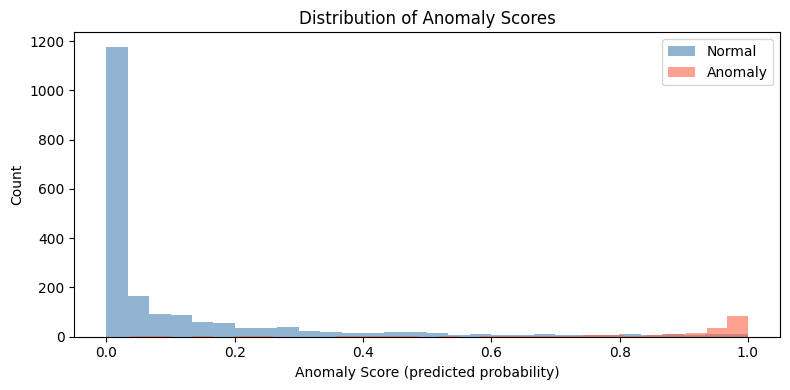

In [14]:
plt.figure(figsize=(8, 4))
plt.hist(y_scores_cv[y == 0], bins=30, alpha=0.6, label="Normal",   color="steelblue")
plt.hist(y_scores_cv[y == 1], bins=30, alpha=0.6, label="Anomaly",  color="tomato")
plt.xlabel("Anomaly Score (predicted probability)")
plt.ylabel("Count")
plt.title("Distribution of Anomaly Scores")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Train Final Model & Generate Submission

We refit on the full training set, then score the held-out test batch.

In [15]:
# ── Fit final stacking ensemble on ALL training data ────────────────────────
stacking.fit(X_with_lof, y)
print("Final stacking ensemble trained on full training set.")

# Also keep plain LR fitted for fallback
pipeline.fit(X_raw_combined, y)
print("Baseline LR pipeline also fitted (for comparison).")


Final stacking ensemble trained on full training set.
Baseline LR pipeline also fitted (for comparison).


In [16]:
# ── Helper: build RAW combined features for any interaction batch ────────────
def build_features_raw(X_interactions, all_items, recon_svd, mean_normal_vec=None):
    df = pd.DataFrame(X_interactions, columns=["user", "item", "rating"])

    pivot = df.pivot_table(
        index="user", columns="item", values="rating", aggfunc="mean"
    ).reindex(columns=all_items, fill_value=0).fillna(0)

    _approx    = recon_svd.transform(pivot.values) @ recon_svd.components_
    _residuals = pivot.values - _approx
    recon_err  = pd.Series(
        np.mean(_residuals ** 2, axis=1),
        index=pivot.index, name="recon_error",
    )

    agg_new = compute_handcrafted_features(df, recon_error=recon_err).loc[pivot.index]

    if mean_normal_vec is not None:
        from sklearn.metrics.pairwise import cosine_similarity
        cos_sim_vals = cosine_similarity(pivot.values, mean_normal_vec).ravel()
        agg_new["cosine_sim_to_normal"] = pd.Series(
            cos_sim_vals, index=pivot.index
        ).reindex(pivot.index).fillna(0)

    # Mahalanobis distance (uses lw fitted on training normal users)
    mahal_test = np.sqrt(lw.mahalanobis(agg_new.values))
    agg_new["mahal_dist"] = mahal_test

    return np.hstack([pivot.values, agg_new.values]), pivot.index.tolist()


def build_features_with_lof(X_interactions, all_items, recon_svd,
                              lof_model, mean_normal_vec=None):
    """
    Extends build_features_raw by appending the LOF outlier score as the
    last column.  Used for stacking ensemble scoring (LGBM arm needs it).
    lof_model : fitted LocalOutlierFactor with novelty=True
    """
    X_base, users = build_features_raw(
        X_interactions, all_items, recon_svd, mean_normal_vec=mean_normal_vec
    )
    # Negate: LOF score_samples higher = more normal → negate for anomaly score
    lof_scores = -lof_model.score_samples(X_base)
    return np.hstack([X_base, lof_scores.reshape(-1, 1)]), users


# ── Score the test batch ──────────────────────────────────────────────────────
data_test  = np.load(os.path.join(data_folder, "second_batch.npz"))
X_test_raw = data_test["X"]

all_items       = user_item.columns.tolist()
mean_normal_vec = user_item.values[(y == 0)].mean(axis=0, keepdims=True)

# Build test features with LOF score for the stacking ensemble
X_test_with_lof, test_users = build_features_with_lof(
    X_test_raw, all_items, _recon_svd, lof, mean_normal_vec=mean_normal_vec
)

# Use best_pipeline-enhanced stacking if grid search ran, otherwise plain stacking
if "best_pipeline" in dir():
    print("Rebuilding stacking ensemble with grid-searched LR arm ...")
    lr_full_best = Pipeline([
        ("cols",  ColumnSelector(end_col=X_raw_combined.shape[1])),
        ("model", CalibratedClassifierCV(best_pipeline, method="sigmoid", cv=3)),
    ])
    score_stacking = StackingClassifier(
        estimators=[("lr", lr_full_best), ("lgbm", lgbm_full)],
        final_estimator=LogisticRegression(
            C=0.1, class_weight="balanced", max_iter=1000, solver="lbfgs", random_state=42
        ),
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        stack_method="predict_proba",
        passthrough=False,
        n_jobs=1,
    )
    score_stacking.fit(X_with_lof, y)
else:
    score_stacking = stacking

anomaly_scores = score_stacking.predict_proba(X_test_with_lof)[:, 1]

print(f"Scored {len(anomaly_scores)} users")
print(f"Score range  : [{anomaly_scores.min():.4f}, {anomaly_scores.max():.4f}]")
print(f"Mean score   : {anomaly_scores.mean():.4f}")

np.savez("submission_ensemble.npz", predictions=anomaly_scores)
print("\nsubmission_ensemble.npz saved!")


Scored 860 users
Score range  : [0.2168, 0.9853]
Mean score   : 0.2863

submission_ensemble.npz saved!


## 8. (Optional) Hyperparameter Tuning

Run this cell to search over regularisation strength `C` and SVD components. This can meaningfully improve AUC.

In [17]:
from sklearn.model_selection import GridSearchCV

# Search over both SVD dimensionality and regularisation strength.
# n_components is now tunable because SVDPlusHandcrafted sits inside the pipeline.
#
# FIX 1: scoring changed from "f1" → "roc_auc".
# Reason: the competition primary metric is AUC.  Optimising F1 at a fixed 0.5
# threshold during grid search is unreliable on imbalanced data — it is
# sensitive to the arbitrary default threshold and can lead to a suboptimal
# decision boundary in probability space.  Tuning for AUC maximises the full
# ROC curve, then we derive the best operating threshold from the PR curve
# afterwards (see cross_val_predict block below).
param_grid = {
    "svd_hc__n_components": [i for i in range(30, 130, 10)],  # sweet spot: 50-120
    "lr__C":                [0.001, 0.01, 0.05, 0.1, 0.5],   # broader log-scale
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring="roc_auc",     # FIX 1: optimise AUC (competition primary metric)
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1,
    refit=True   # automatically refits best params on the full dataset
)

grid_search.fit(X_raw_combined, y)

print(f"Best n_components : {grid_search.best_params_['svd_hc__n_components']}")
print(f"Best C            : {grid_search.best_params_['lr__C']}")
print(f"Best AUC (CV)     : {grid_search.best_score_:.4f}")

# Results table sorted by AUC
results = pd.DataFrame(grid_search.cv_results_)
print(results[
    ["param_svd_hc__n_components", "param_lr__C", "mean_test_score", "std_test_score"]
].sort_values("mean_test_score", ascending=False).head(10).to_string(index=False))

# ── Derive best F1 threshold from the AUC-tuned model ──────────────────────
# Now that the model is tuned for AUC, we find the operating threshold that
# maximises F1 using cross-validated probability scores from the best estimator.
y_scores_grid = cross_val_predict(
    grid_search.best_estimator_, X_raw_combined, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    method="predict_proba"
)[:, 1]

from sklearn.metrics import precision_recall_curve as _prc2
_prec2, _rec2, _thresh2 = _prc2(y, y_scores_grid)
_f1_grid = np.where(
    (_prec2[:-1] + _rec2[:-1]) > 0,
    2 * _prec2[:-1] * _rec2[:-1] / (_prec2[:-1] + _rec2[:-1]),
    0
)
best_f1_threshold_grid = float(_thresh2[np.argmax(_f1_grid)])
y_pred_grid = (y_scores_grid >= best_f1_threshold_grid).astype(int)

from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, classification_report
print(f"\n=== Grid-tuned model (AUC-optimised) ===")
print(f"AUC       : {roc_auc_score(y, y_scores_grid):.4f}")
print(f"Best F1 threshold : {best_f1_threshold_grid:.4f}")
print(f"Precision : {precision_score(y, y_pred_grid):.4f}")
print(f"Recall    : {recall_score(y, y_pred_grid):.4f}")
print(f"F1        : {f1_score(y, y_pred_grid):.4f}")
print()
print(classification_report(y, y_pred_grid, target_names=["Normal", "Anomaly"]))

# Use the best pipeline for all subsequent scoring
best_pipeline = grid_search.best_estimator_


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best n_components : 30
Best C            : 0.5
Best AUC (CV)     : 0.9721
 param_svd_hc__n_components  param_lr__C  mean_test_score  std_test_score
                         30          0.5         0.972063        0.012268
                         40          0.5         0.971188        0.011704
                         50          0.5         0.968900        0.013090
                         60          0.5         0.965963        0.015988
                         70          0.5         0.965013        0.015229
                         30          0.1         0.962962        0.015475
                         40          0.1         0.961737        0.015331
                         50          0.1         0.960650        0.015725
                         80          0.5         0.959287        0.016341
                         60          0.1         0.957050        0.019325

=== Grid-tuned model (AUC-optimised) ===
AUC     